<a href="https://colab.research.google.com/github/Ziyan-spec/College-Project/blob/main/Food_Delivery_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Food Delivery Startup — Data Analysis
### Tools: Pandas · NumPy · Matplotlib · Seaborn

---
## Project Structure
| Step | Description |
|------|-------------|
| 0 | Install & Import Libraries |
| 1 | Load Datasets |
| 2 | Initial Exploration (EDA) |
| 3 | Data Cleaning |
| 4 | Feature Engineering |
| 5 | Merge Tables |
| 6–17 | 12 Business Questions + Visualizations |
| 18 | Final Summary Report |

---




##  Step 0 — Install & Import Libraries
> All libraries come pre-installed in Google Colab. We just import them.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##  Step 1 — Load All Datasets



In [3]:
# ── Dimension Tables ──
customer    = pd.read_csv('dim_customer.csv')
partner     = pd.read_csv('dim_delivery_partner_.csv')
menu        = pd.read_csv('dim_menu_item.csv')
restaurant  = pd.read_csv('dim_restaurant.csv')

# ── Fact Tables ──
orders      = pd.read_csv('fact_orders.csv')
order_items = pd.read_csv('fact_order_items.csv')
delivery    = pd.read_csv('fact_delivery_performance.csv')
ratings     = pd.read_csv('fact_ratings.csv')


##  Step 2 — Initial Data Exploration (EDA)
> Before cleaning, always **look at** your data.

> Check: shape, columns, data types, missing values, sample rows.

In [4]:
#first 5 rows of the main fact table
orders.head()

,order_id,customer_id,restaurant_id,delivery_partner_id,order_timestamp,subtotal_amount,discount_amount,delivery_fee,total_amount,is_cod,is_cancelled
0,ORD202501023439,CUST181110,REST08622,DP05541,2025-01-01 12:00:00,471.62,35.44,30.56,466.74,N,N
1,ORD202501012051,CUST025572,REST02383,DP08091,2025-01-01 12:00:00,255.68,0.00,27.45,283.13,Y,N
2,ORD202501019281,CUST179306,REST14069,DP02021,2025-01-01 12:00:00,428.38,0.00,26.23,454.61,N,N
3,ORD202501000124,CUST191820,REST19745,DP13859,2025-01-01 12:00:00,260.81,0.00,32.75,293.56,N,N
4,ORD202501006518,CUST033760,REST12962,DP09615,2025-01-01 12:00:00,280.33,0.00,25.57,305.90,N,N


In [5]:
# --- Column names and data types ---
print('--- Data Types ---')
print(orders.dtypes)
print('\n--- Shape ---')
print(f'Orders table: {orders.shape[0]} rows × {orders.shape[1]} columns')

--- Data Types ---
order_id                object
customer_id             object
restaurant_id           object
delivery_partner_id     object
order_timestamp         object
subtotal_amount        float64
discount_amount        float64
delivery_fee           float64
total_amount           float64
is_cod                  object
is_cancelled            object
dtype: object

--- Shape ---
Orders table: 149166 rows × 11 columns


In [6]:
# --- Statistics for numeric columns ---
print('--- Descriptive Statistics ---')
orders.describe().round(2)

--- Descriptive Statistics ---


,subtotal_amount,discount_amount,delivery_fee,total_amount
count,149166.00,149166.00,149166.00,149166.00
mean,314.37,18.89,30.07,325.55
std,147.35,29.80,11.00,146.79
min,0.00,0.00,0.00,0.00
25%,234.96,0.00,24.73,249.84
50%,309.07,0.00,31.48,321.70
75%,396.29,34.69,38.24,406.59
max,900.00,222.53,45.00,944.91


In [7]:
# --- Check null / missing values in every table ---
customer.info()
customer.isnull().sum()
customer.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107776 entries, 0 to 107775
Data columns (total 4 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   customer_id          107776 non-null  object
 1   signup_date          107776 non-null  object
 2   city                 107776 non-null  object
 3   acquisition_channel  107776 non-null  object
dtypes: object(4)
memory usage: 3.3+ MB


,customer_id,signup_date,city,acquisition_channel
0,CUST000007,21-03-2025,Pune,Organic
1,CUST000008,07-02-2025,Kolkata,Referral
2,CUST000009,25-02-2025,Delhi,Paid
3,CUST000010,28-01-2025,Hyderabad,Paid
4,CUST000011,18-01-2025,Kolkata,Organic


In [8]:
partner.info()
partner.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   delivery_partner_id  15000 non-null  object 
 1   partner_name         15000 non-null  object 
 2   city                 15000 non-null  object 
 3   vehicle_type         15000 non-null  object 
 4   employment_type      15000 non-null  object 
 5   avg_rating           15000 non-null  float64
 6   is_active            15000 non-null  object 
dtypes: float64(1), object(6)
memory usage: 820.4+ KB


,0
delivery_partner_id,0
partner_name,0
city,0
vehicle_type,0
employment_type,0
avg_rating,0
is_active,0


In [9]:
menu.info()
menu.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 342671 entries, 0 to 342670
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   menu_item_id   342671 non-null  object 
 1   restaurant_id  342671 non-null  object 
 2   item_name      342671 non-null  object 
 3   category       342671 non-null  object 
 4   is_veg         342671 non-null  object 
 5   price          342671 non-null  float64
dtypes: float64(1), object(5)
memory usage: 15.7+ MB


,0
menu_item_id,0
restaurant_id,0
item_name,0
category,0
is_veg,0
price,0


In [10]:
restaurant.info()
restaurant.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19995 entries, 0 to 19994
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   restaurant_id      19995 non-null  object
 1   restaurant_name    19995 non-null  object
 2   city               19995 non-null  object
 3   cuisine_type       19995 non-null  object
 4   partner_type       19995 non-null  object
 5   avg_prep_time_min  19995 non-null  object
 6   is_active          19995 non-null  object
dtypes: object(7)
memory usage: 1.1+ MB


,0
restaurant_id,0
restaurant_name,0
city,0
cuisine_type,0
partner_type,0
avg_prep_time_min,0
is_active,0


In [11]:
orders.info()
orders.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149166 entries, 0 to 149165
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             149166 non-null  object 
 1   customer_id          149166 non-null  object 
 2   restaurant_id        149166 non-null  object 
 3   delivery_partner_id  143531 non-null  object 
 4   order_timestamp      149166 non-null  object 
 5   subtotal_amount      149166 non-null  float64
 6   discount_amount      149166 non-null  float64
 7   delivery_fee         149166 non-null  float64
 8   total_amount         149166 non-null  float64
 9   is_cod               149166 non-null  object 
 10  is_cancelled         149166 non-null  object 
dtypes: float64(4), object(7)
memory usage: 12.5+ MB


,0
order_id,0
customer_id,0
restaurant_id,0
delivery_partner_id,5635
order_timestamp,0
subtotal_amount,0
discount_amount,0
delivery_fee,0
total_amount,0
is_cod,0


In [12]:
order_items.info()
order_items.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 342994 entries, 0 to 342993
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   order_id       342994 non-null  object 
 1   item_id        342994 non-null  object 
 2   menu_item_id   342994 non-null  object 
 3   restaurant_id  342994 non-null  object 
 4   quantity       342994 non-null  int64  
 5   unit_price     342994 non-null  float64
 6   item_discount  342994 non-null  float64
 7   line_total     342994 non-null  float64
dtypes: float64(3), int64(1), object(4)
memory usage: 20.9+ MB


,0
order_id,0
item_id,0
menu_item_id,0
restaurant_id,0
quantity,0
unit_price,0
item_discount,0
line_total,0


In [13]:
delivery.info()
delivery.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149166 entries, 0 to 149165
Data columns (total 4 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   order_id                     149166 non-null  object 
 1   actual_delivery_time_mins    149166 non-null  int64  
 2   expected_delivery_time_mins  149166 non-null  int64  
 3   distance_km                  149166 non-null  float64
dtypes: float64(1), int64(2), object(1)
memory usage: 4.6+ MB


,0
order_id,0
actual_delivery_time_mins,0
expected_delivery_time_mins,0
distance_km,0


In [14]:
ratings.info()
ratings.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68842 entries, 0 to 68841
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          68825 non-null  object 
 1   customer_id       68825 non-null  object 
 2   restaurant_id     68825 non-null  object 
 3   rating            68825 non-null  float64
 4   review_text       68825 non-null  object 
 5   review_timestamp  68825 non-null  object 
 6   sentiment_score   68825 non-null  float64
dtypes: float64(2), object(5)
memory usage: 3.7+ MB


,0
order_id,17
customer_id,17
restaurant_id,17
rating,17
review_text,17
review_timestamp,17
sentiment_score,17


## 🧹 Step 3 — Data Cleaning
> Fix data types, handle nulls, remove duplicates, standardise columns.

> **Rule:** Never delete rows without understanding WHY they're missing.

In [15]:
# --- Fix date/time columns ---
# Convert string dates to proper datetime so we can extract hour, day, month
orders['order_timestamp'] = pd.to_datetime(orders['order_timestamp'])
customer['signup_date'] = pd.to_datetime(customer['signup_date'], dayfirst=True)
ratings['review_timestamp'] = pd.to_datetime(ratings['review_timestamp'], dayfirst=True)
print('Date columns fixed')

# --- Fill missing delivery_partner_id ---
# Cancelled orders have no partner (no one delivered them) → fill with UNASSIGNED
orders['delivery_partner_id'] = orders['delivery_partner_id'].fillna('UNASSIGNED')
print('Filled missing delivery_partner_id with UNASSIGNED')

# --- Remove null values from ratings table ---
ratings.dropna(inplace=True)
print('Removed the null values')

# --- Remove duplicate rows ---
orders = orders.drop_duplicates()
print('Removed duplicate rows from orders table')

# --- Convert Y/N columns to 0/1 integers ---
orders['is_cancelled_flag'] = (orders['is_cancelled'] == 'Y').astype(int)
orders['is_cod_flag'] = (orders['is_cod'] == 'Y').astype(int)
print('Converted Y/N columns to 0/1')

print('\n--- Orders table after cleaning ---')
print(f'Shape: {orders.shape}')
print(f'Null values: {orders.isnull().sum().sum()}')

Date columns fixed
Filled missing delivery_partner_id with UNASSIGNED
Removed the null values
Removed duplicate rows from orders table
Converted Y/N columns to 0/1

--- Orders table after cleaning ---
Shape: (149166, 13)
Null values: 0


##  Step 4 — Feature Engineering
> Create **new columns** from existing data to unlock richer analysis.

> Example: from `order_timestamp` we can extract hour, day, month.

In [16]:
# --- Time features from order timestamp ---
orders['order_hour'] = orders['order_timestamp'].dt.hour
orders['order_day'] = orders['order_timestamp'].dt.day_name()
orders['order_month'] = orders['order_timestamp'].dt.to_period('M').astype(str)

# --- Delivery delay: positive = late, negative = early ---
delivery['delay_mins'] = delivery['actual_delivery_time_mins'] - delivery['expected_delivery_time_mins']
delivery['is_late']    = (delivery['delay_mins'] > 0).astype(int)

# --- Discount rate as % of subtotal ---
orders['discount_rate'] = (orders['discount_amount'] / orders['subtotal_amount'] * 100).round(2)

# --- Time of day buckets ---
def time_bucket(hour):
    if 6 <= hour < 12:    return 'Morning'
    elif 12 <= hour < 16: return 'Lunch'
    elif 16 <= hour < 20: return 'Evening'
    else:                 return 'Night'

orders['time_of_day'] = orders['order_hour'].apply(time_bucket)

print('New columns created:')
print('   orders   → order_hour, order_day, order_month, time_of_day, discount_rate')
print('   delivery → delay_mins, is_late')
orders[['order_id','order_hour','order_day','time_of_day','discount_rate']].head()

New columns created:
   orders   → order_hour, order_day, order_month, time_of_day, discount_rate
   delivery → delay_mins, is_late


,order_id,order_hour,order_day,time_of_day,discount_rate
0,ORD202501023439,12,Wednesday,Lunch,7.51
1,ORD202501012051,12,Wednesday,Lunch,0.00
2,ORD202501019281,12,Wednesday,Lunch,0.00
3,ORD202501000124,12,Wednesday,Lunch,0.00
4,ORD202501006518,12,Wednesday,Lunch,0.00


## Step 5 — Merge Tables
> Join dim and fact tables using shared key columns (like `customer_id`, `restaurant_id`).

> This creates a **master dataframe** ready for analysis.

In [17]:
# --- Orders + Customer city ---
orders_cust = orders.merge(
    customer[['customer_id','city','acquisition_channel']],
    on='customer_id', how='left'
)
orders_cust.rename(columns={'city': 'customer_city'}, inplace=True)

# --- + Restaurant info ---
orders_rest = orders_cust.merge(
    restaurant[['restaurant_id','restaurant_name','cuisine_type','avg_prep_time_min']],
    on='restaurant_id', how='left'
)

# --- + Delivery performance ---
master = orders_rest.merge(delivery, on='order_id', how='left')

# --- Order items + Menu item details ---
items_menu = order_items.merge(
    menu[['menu_item_id','item_name','category','is_veg','price']],
    on='menu_item_id', how='left'
)
items_menu = items_menu.merge(
    restaurant[['restaurant_id','cuisine_type']], on='restaurant_id', how='left'
)

# --- Filter only COMPLETED orders for revenue analysis ---
active = master[master['is_cancelled'] == 'N']

print(f'Master table  : {master.shape[0]:,} rows × {master.shape[1]} columns')
print(f'Items+menu    : {items_menu.shape[0]:,} rows × {items_menu.shape[1]} columns')
print(f'Active orders : {len(active):,} (cancelled excluded)')
master.head(3)

Master table  : 149,166 rows × 28 columns
Items+menu    : 342,994 rows × 13 columns
Active orders : 138,054 (cancelled excluded)


,order_id,customer_id,restaurant_id,delivery_partner_id,order_timestamp,subtotal_amount,discount_amount,delivery_fee,total_amount,is_cod,...,customer_city,acquisition_channel,restaurant_name,cuisine_type,avg_prep_time_min,actual_delivery_time_mins,expected_delivery_time_mins,distance_km,delay_mins,is_late
0,ORD202501023439,CUST181110,REST08622,DP05541,2025-01-01 12:00:00,471.62,35.44,30.56,466.74,N,...,Hyderabad,Social,Spicy Wraps Point,North Indian,16-25,31,31,6.4,0,0
1,ORD202501012051,CUST025572,REST02383,DP08091,2025-01-01 12:00:00,255.68,0.00,27.45,283.13,Y,...,Bengaluru,Organic,Namma Mess Delight,Healthy,26-40,46,42,1.9,4,1
2,ORD202501019281,CUST179306,REST14069,DP02021,2025-01-01 12:00:00,428.38,0.00,26.23,454.61,N,...,Kolkata,Organic,Royal Biryani Darbar,Fast Food,16-25,25,31,6.2,-6,0


---
## Q1 — Which city generates the most orders & revenue?
> **Business use:** Decide where to invest in marketing and expand operations.

Top 8 Cities:
customer_city  total_orders  total_revenue  avg_order_val
    Bengaluru         38862    13683716.11         352.11
       Mumbai         22213     7807738.69         351.49
        Delhi         19404     6800897.38         350.49
      Chennai         13940     4907118.16         352.02
    Hyderabad         13573     4780799.17         352.23
         Pune         11018     3876148.64         351.80
    Ahmedabad          9562     3367674.04         352.19
      Kolkata          9482     3337023.37         351.93


/tmp/ipykernel_16572/3291094536.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=city_stats.head(8), x='customer_city', y='total_orders',
/tmp/ipykernel_16572/3291094536.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=city_stats.head(8), x='customer_city', y='total_revenue',


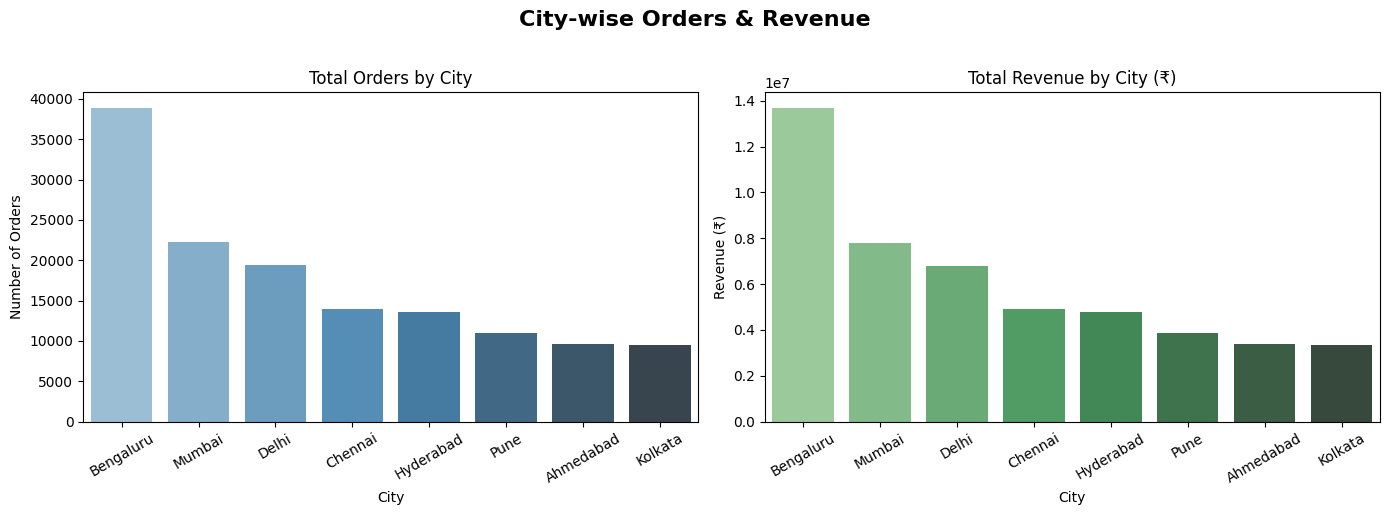


Insight: Bengaluru leads in both orders and revenue.


In [18]:
city_stats = active.groupby('customer_city').agg(
    total_orders  = ('order_id', 'count'),
    total_revenue = ('total_amount', 'sum'),
    avg_order_val = ('total_amount', 'mean')
).sort_values('total_revenue', ascending=False).reset_index()

print('Top 8 Cities:')
print(city_stats.head(8).round(2).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=city_stats.head(8), x='customer_city', y='total_orders',
            palette='Blues_d', ax=axes[0])
axes[0].set_title('Total Orders by City')
axes[0].set_xlabel('City'); axes[0].set_ylabel('Number of Orders')
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(data=city_stats.head(8), x='customer_city', y='total_revenue',
            palette='Greens_d', ax=axes[1])
axes[1].set_title('Total Revenue by City (₹)')
axes[1].set_xlabel('City'); axes[1].set_ylabel('Revenue (₹)')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('City-wise Orders & Revenue', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('q1_city.png', dpi=120, bbox_inches='tight')
plt.show()
print('\nInsight: Bengaluru leads in both orders and revenue.')

---
## Q2 — Which food categories sell the most?
> **Business use:** Prioritise menu development and promotional offers.

Top 10 Food Categories:
  category  total_qty  total_revenue
 Beverages     108769     7791188.23
  Starters     104131     7500718.99
   Biryani      68871     5028080.00
   Noodles      34426     2486968.50
    Breads      34185     2457712.69
Fried Rice      34058     2465751.07
   Curries      33916     2425754.30
  Desserts      29070     2060268.44
     Pizza      26946     1932034.26
     Sides      26675     1910225.30


/tmp/ipykernel_16572/1945623984.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_sales.head(10), y='category', x='total_qty',


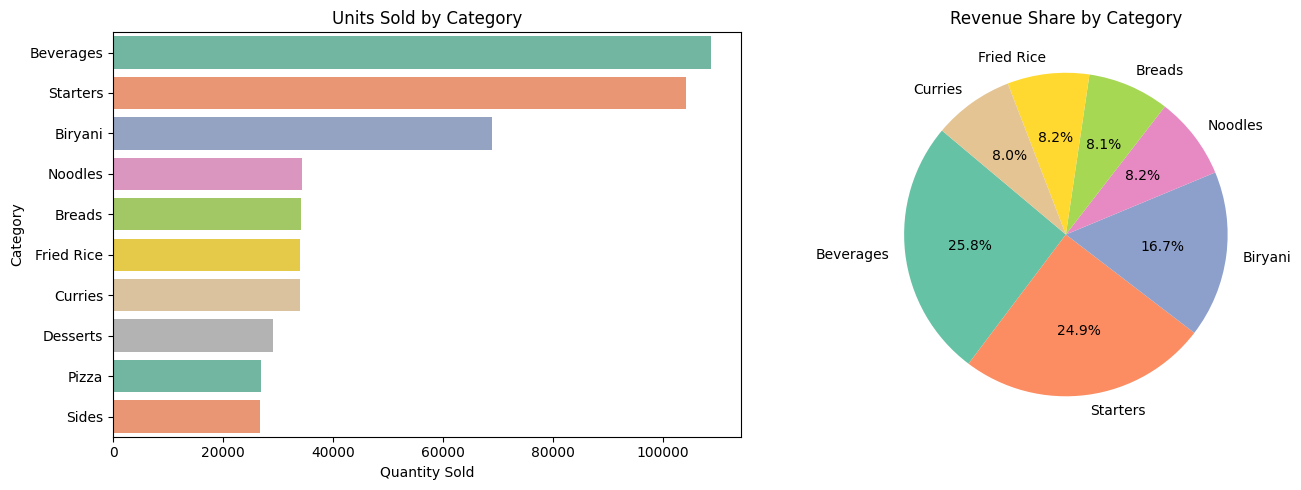


 Insight: Identify which categories generate the most revenue.


In [19]:
cat_sales = items_menu.groupby('category').agg(
    total_qty     = ('quantity', 'sum'),
    total_revenue = ('line_total', 'sum')
).sort_values('total_qty', ascending=False).reset_index()

print('Top 10 Food Categories:')
print(cat_sales.head(10).round(2).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=cat_sales.head(10), y='category', x='total_qty',
            palette='Set2', ax=axes[0])
axes[0].set_title('Units Sold by Category')
axes[0].set_xlabel('Quantity Sold'); axes[0].set_ylabel('Category')

top7 = cat_sales.head(7)
axes[1].pie(top7['total_revenue'], labels=top7['category'],
            autopct='%1.1f%%', startangle=140,
            colors=sns.color_palette('Set2', len(top7)))
axes[1].set_title('Revenue Share by Category')

plt.tight_layout()
plt.savefig('q2_categories.png', dpi=120, bbox_inches='tight')
plt.show()
print('\n Insight: Identify which categories generate the most revenue.')

---
## Q3 — What time of day do most orders arrive?
> **Business use:** Schedule delivery partners and kitchen staff at peak hours.

/tmp/ipykernel_16572/2154828458.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tod, x='time_of_day', y='orders', palette='rocket', ax=axes[1])


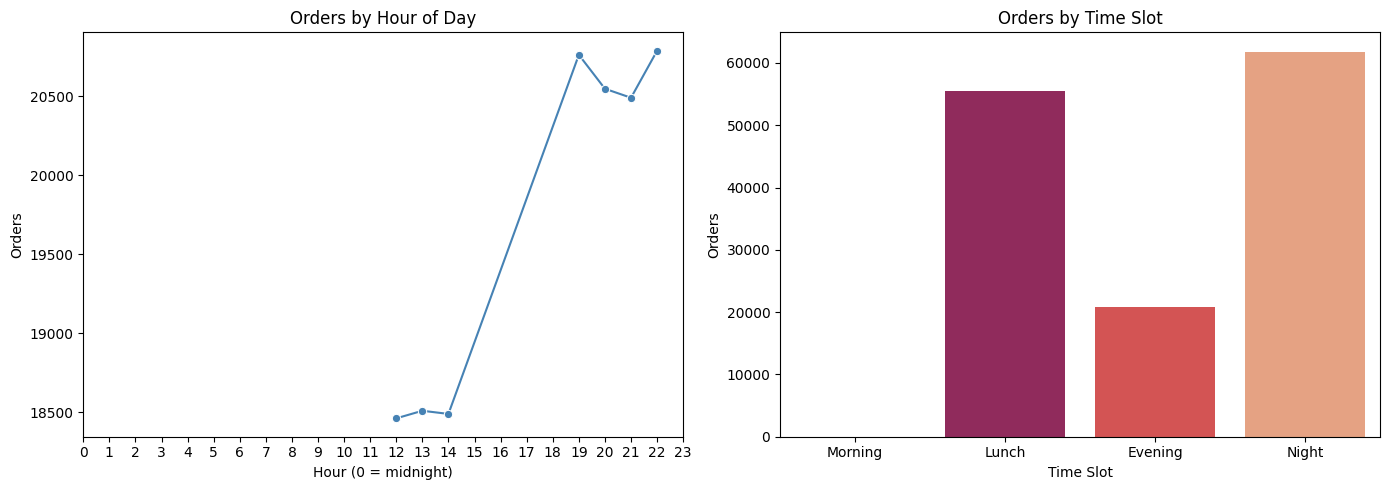


Insight: Peak hours are Lunch (12–14) and Evening/Night (19–21).


In [20]:
hourly    = active.groupby('order_hour')['order_id'].count().reset_index(name='orders')
tod_order = ['Morning', 'Lunch', 'Evening', 'Night']
tod = active.groupby('time_of_day')['order_id'].count().reset_index(name='orders')
tod['time_of_day'] = pd.Categorical(tod['time_of_day'], categories=tod_order, ordered=True)
tod = tod.sort_values('time_of_day')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=hourly, x='order_hour', y='orders',
             marker='o', color='steelblue', ax=axes[0])
axes[0].set_title('Orders by Hour of Day')
axes[0].set_xlabel('Hour (0 = midnight)'); axes[0].set_ylabel('Orders')
axes[0].set_xticks(range(0, 24))

sns.barplot(data=tod, x='time_of_day', y='orders', palette='rocket', ax=axes[1])
axes[1].set_title('Orders by Time Slot')
axes[1].set_xlabel('Time Slot'); axes[1].set_ylabel('Orders')

plt.tight_layout()
plt.savefig('q3_time.png', dpi=120, bbox_inches='tight')
plt.show()
print('\nInsight: Peak hours are Lunch (12–14) and Evening/Night (19–21).')

---
## Q4 — How has revenue trended over time?
> **Business use:** Track growth, spot seasonal trends, plan targets.

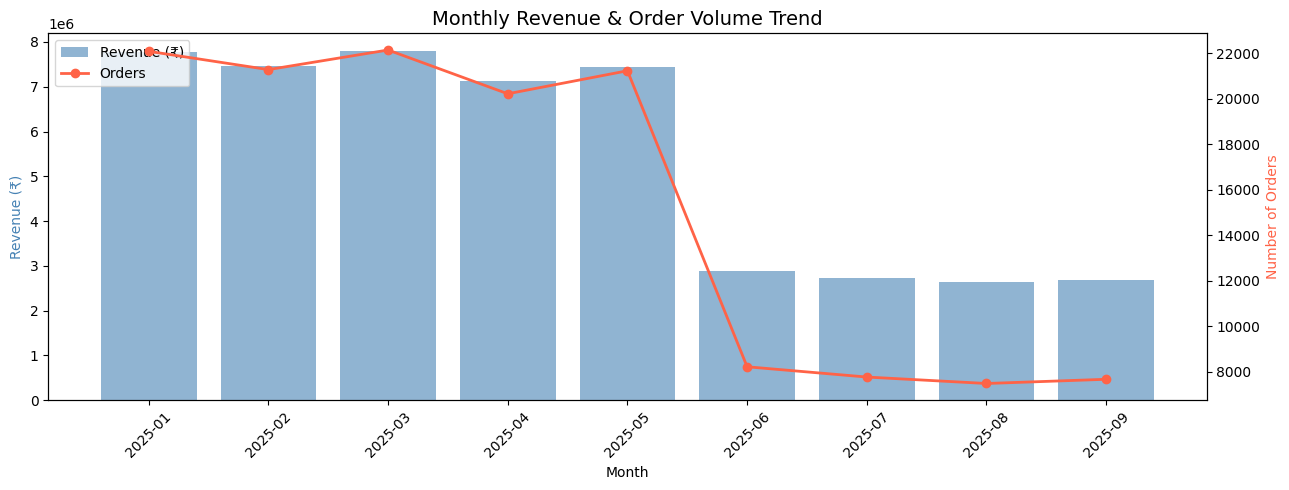


Insight: Identify growth months and seasonal revenue dips.


In [33]:
monthly = active.groupby('order_month').agg(
    revenue = ('total_amount', 'sum'),
    orders  = ('order_id', 'count')
).reset_index().sort_values('order_month')

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()   # Second y-axis on the same chart

ax1.bar(monthly['order_month'], monthly['revenue'],
        color='steelblue', alpha=0.6, label='Revenue (₹)')
ax2.plot(monthly['order_month'], monthly['orders'],
         color='tomato', marker='o', linewidth=2, label='Orders')

ax1.set_title('Monthly Revenue & Order Volume Trend', fontsize=14)
ax1.set_xlabel('Month')
ax1.set_ylabel('Revenue (₹)', color='steelblue')
ax2.set_ylabel('Number of Orders', color='tomato')
ax1.tick_params(axis='x', rotation=45)

l1, lb1 = ax1.get_legend_handles_labels()
l2, lb2 = ax2.get_legend_handles_labels()
ax1.legend(l1+l2, lb1+lb2, loc='upper left')

plt.tight_layout()
plt.savefig('q4_trend.png', dpi=120, bbox_inches='tight')
plt.show()
print('\nInsight: Identify growth months and seasonal revenue dips.')

---
##  Q5 — What is the cancellation pattern?
> **Business use:** Find which cities/time slots have the highest drop-off — fix them.

Overall Cancellation Rate: 7.45%


/tmp/ipykernel_16572/2095263325.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cancel_by_city.head(8), x='city', y='cancel_rate_%',
/tmp/ipykernel_16572/2095263325.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cancel_by_tod, x='time_of_day', y='cancel_rate_%',


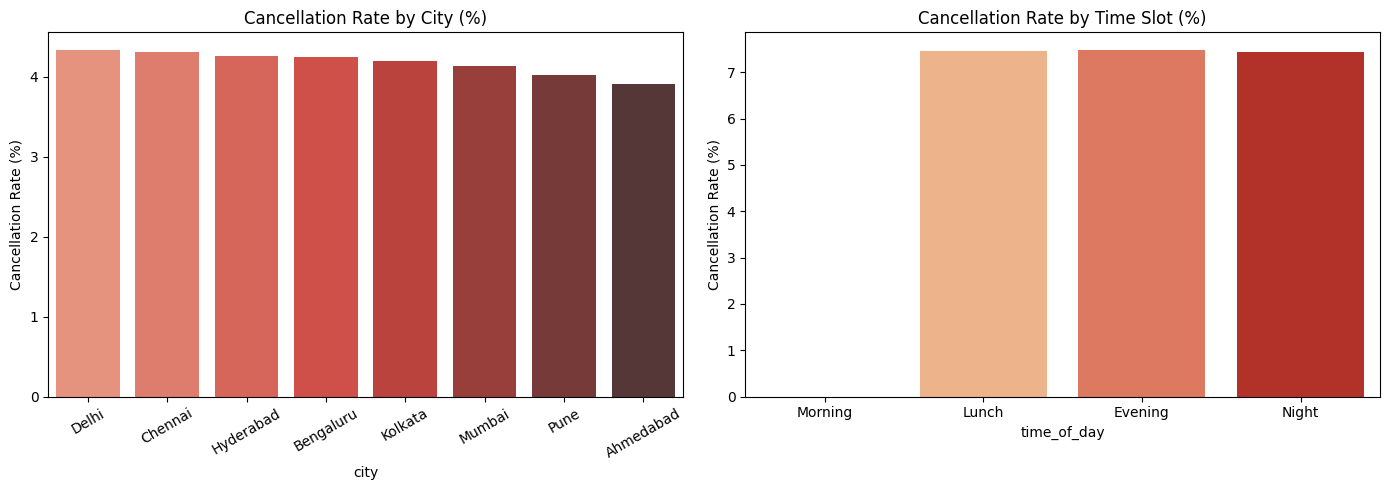


Insight: Target problem cities and slots to reduce cancellations.


In [34]:
cancel_rate = orders['is_cancelled_flag'].mean() * 100
print(f'Overall Cancellation Rate: {cancel_rate:.2f}%')

cancel_by_city = master.groupby('customer_city')['is_cancelled_flag'] \
    .mean().mul(100).sort_values(ascending=False).reset_index()
cancel_by_city.columns = ['city', 'cancel_rate_%']

cancel_by_tod = master.groupby('time_of_day')['is_cancelled_flag'] \
    .mean().mul(100).reset_index()
cancel_by_tod.columns = ['time_of_day', 'cancel_rate_%']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=cancel_by_city.head(8), x='city', y='cancel_rate_%',
            palette='Reds_d', ax=axes[0])
axes[0].set_title('Cancellation Rate by City (%)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].set_ylabel('Cancellation Rate (%)')

sns.barplot(data=cancel_by_tod, x='time_of_day', y='cancel_rate_%',
            order=['Morning','Lunch','Evening','Night'],
            palette='OrRd', ax=axes[1])
axes[1].set_title('Cancellation Rate by Time Slot (%)')
axes[1].set_ylabel('Cancellation Rate (%)')

plt.tight_layout()
plt.savefig('q5_cancellation.png', dpi=120, bbox_inches='tight')
plt.show()
print('\nInsight: Target problem cities and slots to reduce cancellations.')

---
##  Q6 — How bad is the late delivery problem?
> **Business use:** Set SLA targets, manage partner performance, improve customer satisfaction.

Late Delivery Rate  : 63.84%
Avg Delay (mins)    : 5.71


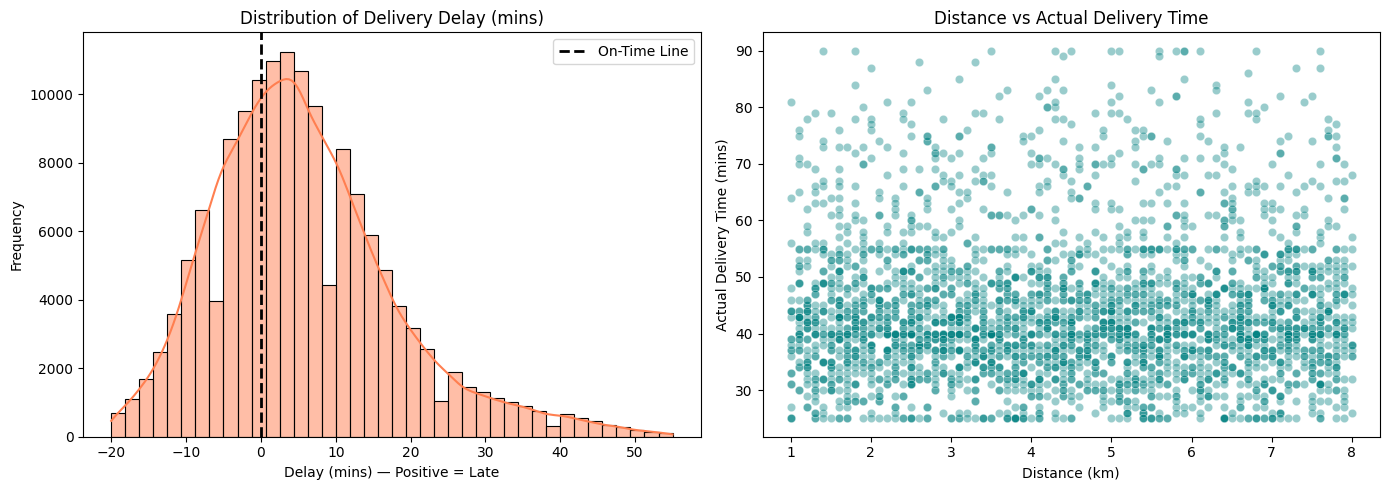


Insight: 63.84% of deliveries are late — biggest operational problem!


In [35]:
late_rate = delivery['is_late'].mean() * 100
avg_delay = delivery['delay_mins'].mean()
print(f'Late Delivery Rate  : {late_rate:.2f}%')
print(f'Avg Delay (mins)    : {avg_delay:.2f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(delivery['delay_mins'], bins=40, color='coral', kde=True, ax=axes[0])
axes[0].axvline(0, color='black', linestyle='--', linewidth=2, label='On-Time Line')
axes[0].set_title('Distribution of Delivery Delay (mins)')
axes[0].set_xlabel('Delay (mins) — Positive = Late')
axes[0].set_ylabel('Frequency'); axes[0].legend()

sample = delivery.sample(min(3000, len(delivery)), random_state=42)
sns.scatterplot(data=sample, x='distance_km', y='actual_delivery_time_mins',
                alpha=0.4, color='teal', ax=axes[1])
axes[1].set_title('Distance vs Actual Delivery Time')
axes[1].set_xlabel('Distance (km)')
axes[1].set_ylabel('Actual Delivery Time (mins)')

plt.tight_layout()
plt.savefig('q6_delivery.png', dpi=120, bbox_inches='tight')
plt.show()
print('\nInsight: 63.84% of deliveries are late — biggest operational problem!')

---
##  Q7 — Which customer acquisition channel performs best?
> **Business use:** Allocate marketing budget to the most profitable channels.

acquisition_channel  orders     revenue
            Organic   75778 25525974.55
               Paid   32690 10985405.78
           Referral   20818  7028724.29
             Social   14827  5021010.94


/tmp/ipykernel_16572/488471894.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=acq, x='acquisition_channel', y='orders', palette='Set1', ax=axes[0])


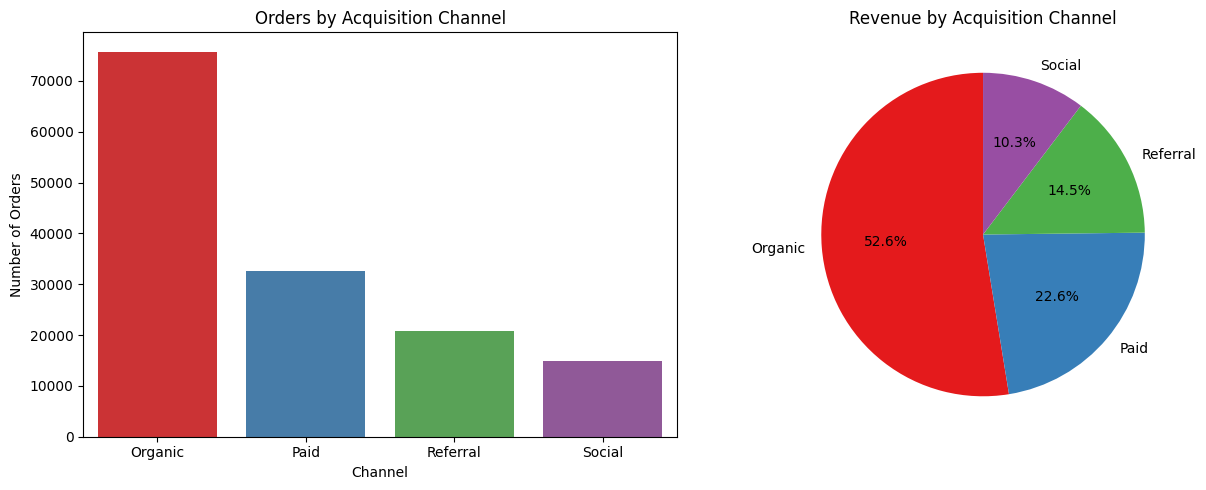


Insight: Which channel brings highest-value customers?


In [36]:
acq = orders_cust.groupby('acquisition_channel')['order_id'] \
    .count().reset_index(name='orders')
acq_rev = orders_cust[orders_cust['is_cancelled']=='N'] \
    .groupby('acquisition_channel')['total_amount'].sum().reset_index(name='revenue')
acq = acq.merge(acq_rev, on='acquisition_channel').sort_values('revenue', ascending=False)
print(acq.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(data=acq, x='acquisition_channel', y='orders', palette='Set1', ax=axes[0])
axes[0].set_title('Orders by Acquisition Channel')
axes[0].set_xlabel('Channel'); axes[0].set_ylabel('Number of Orders')

axes[1].pie(acq['revenue'], labels=acq['acquisition_channel'],
            autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('Set1', len(acq)))
axes[1].set_title('Revenue by Acquisition Channel')

plt.tight_layout()
plt.savefig('q7_acquisition.png', dpi=120, bbox_inches='tight')
plt.show()
print('\nInsight: Which channel brings highest-value customers?')

---
##  Q8 — How are restaurants rated across cuisine types?
> **Business use:** Identify high-performing cuisines, help low-rated ones improve.

Average Rating     : 4.05 / 5
Avg Sentiment Score: 0.53


/tmp/ipykernel_16572/3697055076.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cuisine_rating.head(10), x='rating', y='cuisine_type',


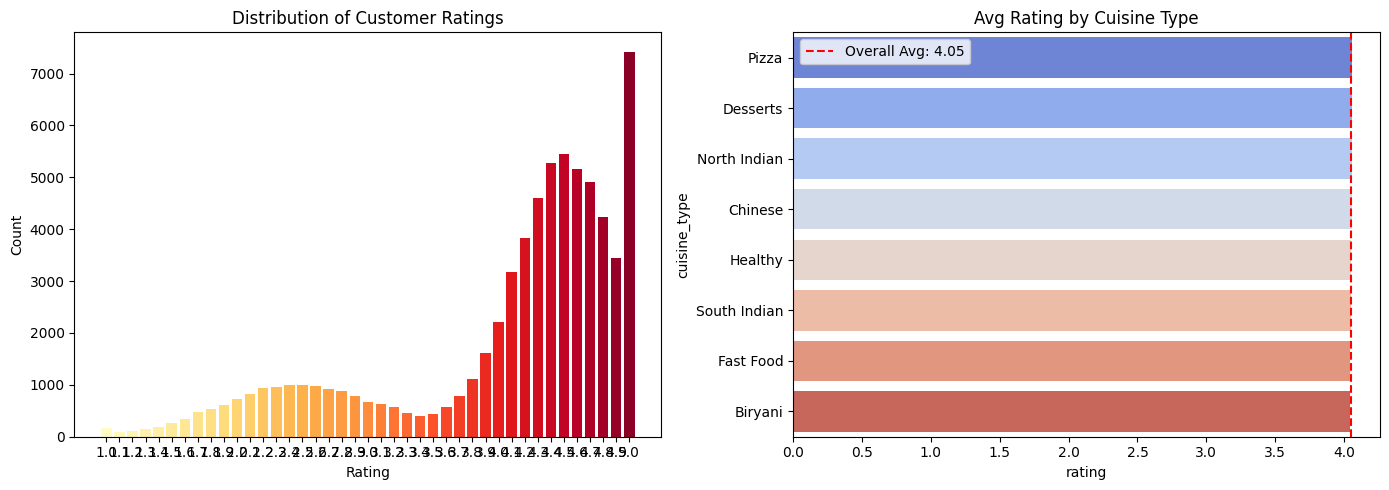


Insight: See which cuisines consistently satisfy customers.


In [38]:
ratings['rating'] = pd.to_numeric(ratings['rating'], errors='coerce')
ratings = ratings.dropna(subset=['rating'])

print(f'Average Rating     : {ratings["rating"].mean():.2f} / 5')
print(f'Avg Sentiment Score: {ratings["sentiment_score"].mean():.2f}')

rat_rest = ratings.merge(restaurant[['restaurant_id','cuisine_type']],
                          on='restaurant_id', how='left')
cuisine_rating = rat_rest.groupby('cuisine_type')['rating'] \
    .mean().sort_values(ascending=False).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rating_counts = ratings['rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index.astype(str), rating_counts.values,
            color=sns.color_palette('YlOrRd', len(rating_counts)))
axes[0].set_title('Distribution of Customer Ratings')
axes[0].set_xlabel('Rating'); axes[0].set_ylabel('Count')

sns.barplot(data=cuisine_rating.head(10), x='rating', y='cuisine_type',
            palette='coolwarm', ax=axes[1])
axes[1].set_title('Avg Rating by Cuisine Type')
axes[1].axvline(ratings['rating'].mean(), color='red', linestyle='--',
                label=f'Overall Avg: {ratings["rating"].mean():.2f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('q8_ratings.png', dpi=120, bbox_inches='tight')
plt.show()
print('\nInsight: See which cuisines consistently satisfy customers.')

---
##  Q9 — What variables are correlated? (Statistical Analysis)
> **Business use:** Understand relationships between order value, delivery time, discounts.

Correlation Matrix:
                           subtotal_amount  discount_amount  delivery_fee  \
subtotal_amount                       1.00             0.30          0.47   
discount_amount                       0.30             1.00          0.14   
delivery_fee                          0.47             0.14          1.00   
total_amount                          0.98             0.10          0.52   
actual_delivery_time_mins            -0.04            -0.02         -0.05   
distance_km                           0.00             0.00          0.00   
delay_mins                           -0.03            -0.01         -0.04   

                           total_amount  actual_delivery_time_mins  \
subtotal_amount                    0.98                      -0.04   
discount_amount                    0.10                      -0.02   
delivery_fee                       0.52                      -0.05   
total_amount                       1.00                      -0.04   
actual_delive

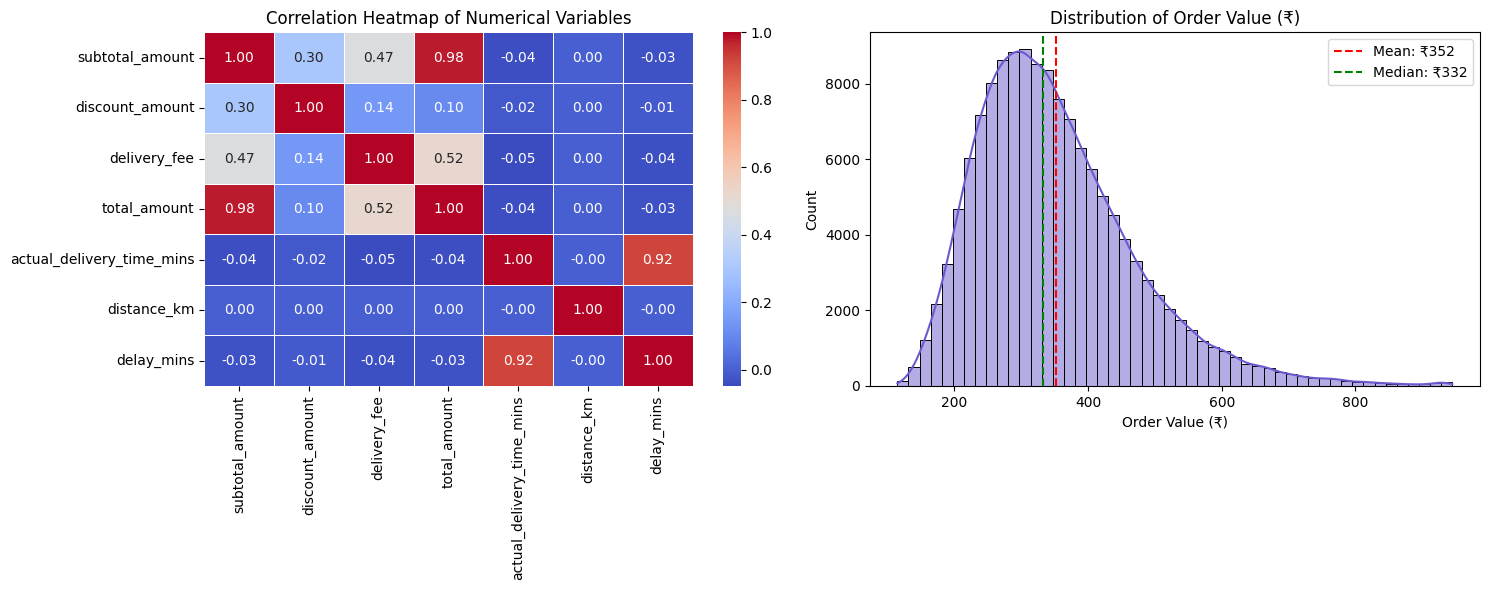


Insight: Distance and delivery time are strongly correlated.


In [39]:
num_cols = master[['subtotal_amount','discount_amount','delivery_fee',
                   'total_amount','actual_delivery_time_mins',
                   'distance_km','delay_mins']].dropna()
corr = num_cols.corr()

print('Correlation Matrix:')
print(corr.round(2))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Correlation Heatmap of Numerical Variables')

sns.histplot(active['total_amount'], bins=50, kde=True, color='slateblue', ax=axes[1])
axes[1].axvline(active['total_amount'].mean(), color='red', linestyle='--',
                label=f'Mean: ₹{active["total_amount"].mean():.0f}')
axes[1].axvline(active['total_amount'].median(), color='green', linestyle='--',
                label=f'Median: ₹{active["total_amount"].median():.0f}')
axes[1].set_title('Distribution of Order Value (₹)')
axes[1].set_xlabel('Order Value (₹)')
axes[1].legend()

plt.tight_layout()
plt.savefig('q9_stats.png', dpi=120, bbox_inches='tight')
plt.show()
print('\nInsight: Distance and delivery time are strongly correlated.')

---
##  Q10 — Veg vs Non-Veg: Who wins?
> **Business use:** Know your customer preference to design menu and marketing.

         label    qty     revenue  avg_price
Non-Vegetarian 233919 16884267.82  72.179976
    Vegetarian 451387 32443164.80  71.874389


/tmp/ipykernel_16572/3569957746.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=veg, x='label', y='avg_price',


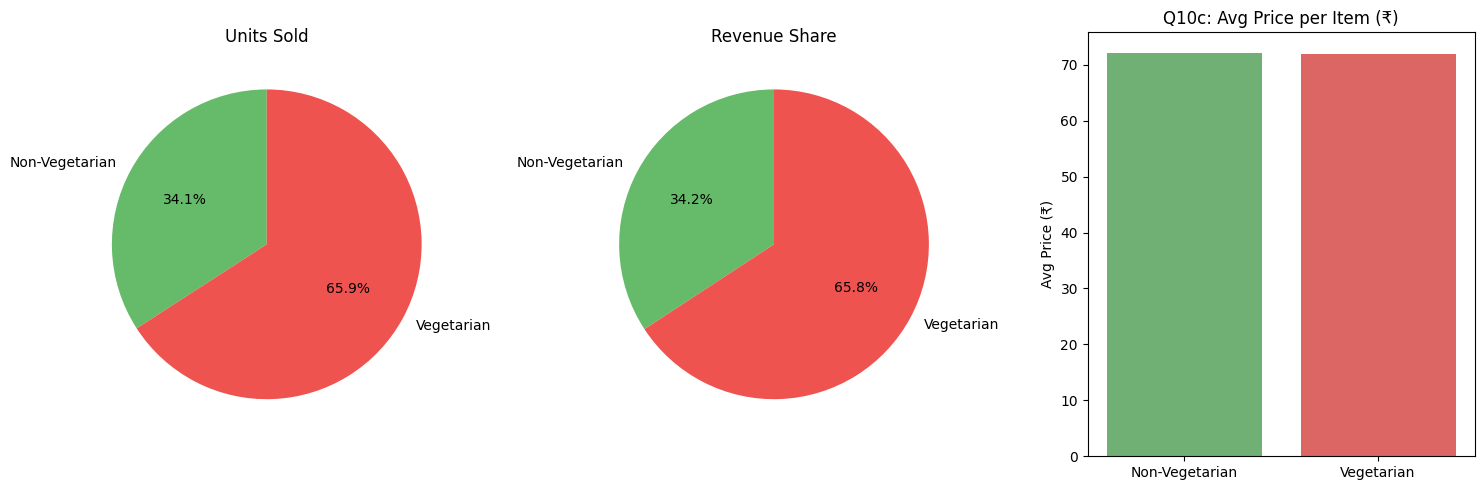


Insight: Which segment drives more revenue per item?


In [40]:
veg = items_menu.groupby('is_veg').agg(
    qty     = ('quantity', 'sum'),
    revenue = ('line_total', 'sum')
).reset_index()
veg['label']     = veg['is_veg'].map({'Y': 'Vegetarian', 'N': 'Non-Vegetarian'})
veg['avg_price'] = veg['revenue'] / veg['qty']
print(veg[['label','qty','revenue','avg_price']].to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].pie(veg['qty'], labels=veg['label'], autopct='%1.1f%%',
            colors=['#66BB6A','#EF5350'], startangle=90)
axes[0].set_title('Units Sold')

axes[1].pie(veg['revenue'], labels=veg['label'], autopct='%1.1f%%',
            colors=['#66BB6A','#EF5350'], startangle=90)
axes[1].set_title('Revenue Share')

sns.barplot(data=veg, x='label', y='avg_price',
            palette=['#66BB6A','#EF5350'], ax=axes[2])
axes[2].set_title('Q10c: Avg Price per Item (₹)')
axes[2].set_xlabel(''); axes[2].set_ylabel('Avg Price (₹)')

plt.tight_layout()
plt.savefig('q10_veg.png', dpi=120, bbox_inches='tight')
plt.show()
print('\nInsight: Which segment drives more revenue per item?')

---
##  Q11 — Do discounts drive bigger orders?
> **Business use:** Evaluate if discount campaigns are profitable or just costly.

discount_bucket  orders  avg_total
    No Discount   82678     372.14
          ₹1–25    9496     264.24
         ₹26–75   36177     311.65
        ₹76–200    9689     412.86
          ₹200+      14     704.84


/tmp/ipykernel_16572/448215438.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=discount_impact, x='discount_bucket', y='orders',
/tmp/ipykernel_16572/448215438.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=discount_impact, x='discount_bucket', y='avg_total',


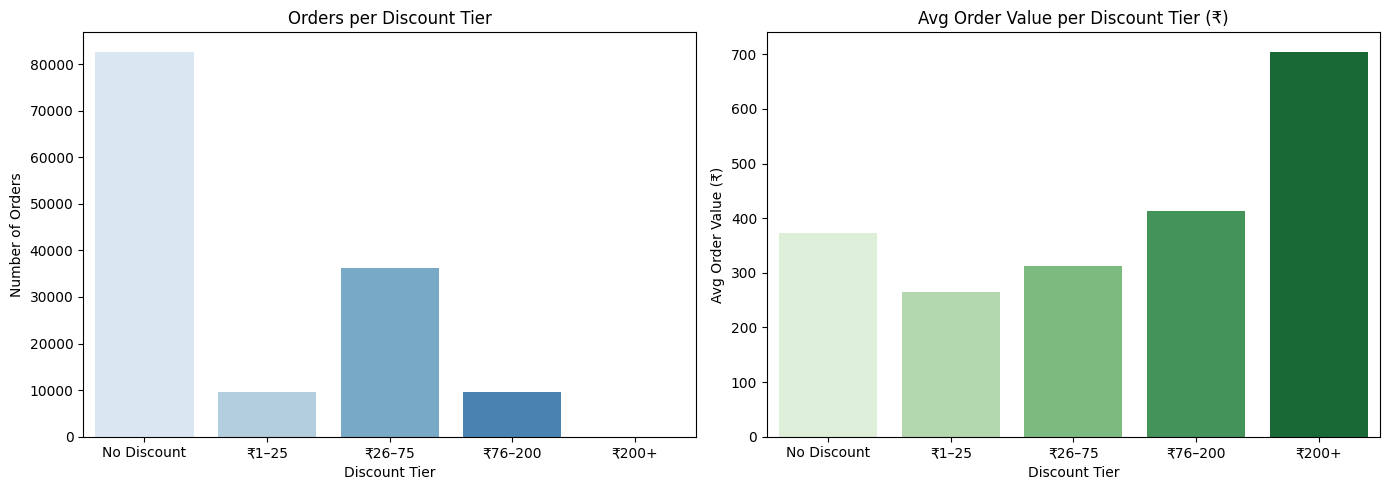


Insight: Higher discounts may attract larger basket sizes.


In [41]:
active2 = active.copy()
active2['discount_bucket'] = pd.cut(
    active2['discount_amount'],
    bins=[-1, 0, 25, 75, 200, 10000],
    labels=['No Discount', '₹1–25', '₹26–75', '₹76–200', '₹200+']
)
discount_impact = active2.groupby('discount_bucket', observed=True).agg(
    orders    = ('order_id', 'count'),
    avg_total = ('total_amount', 'mean')
).reset_index()
print(discount_impact.round(2).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=discount_impact, x='discount_bucket', y='orders',
            palette='Blues', ax=axes[0])
axes[0].set_title('Orders per Discount Tier')
axes[0].set_xlabel('Discount Tier'); axes[0].set_ylabel('Number of Orders')

sns.barplot(data=discount_impact, x='discount_bucket', y='avg_total',
            palette='Greens', ax=axes[1])
axes[1].set_title('Avg Order Value per Discount Tier (₹)')
axes[1].set_xlabel('Discount Tier'); axes[1].set_ylabel('Avg Order Value (₹)')

plt.tight_layout()
plt.savefig('q11_discounts.png', dpi=120, bbox_inches='tight')
plt.show()
print('\nInsight: Higher discounts may attract larger basket sizes.')

---
##  Q12 — Who are the top 10 restaurants by revenue?
> **Business use:** Strengthen partnerships with star restaurants; support weaker ones.

              restaurant_name cuisine_type  revenue  orders
Hot & Crispy Pizza Bhojanalay      Biryani  8318.71      21
      Punjabi Darshini Palace      Biryani  7184.13      20
    Hot & Crispy Paratha Zone     Desserts  6831.62      18
     Thindi Mane Grill Palace      Chinese  6689.00      21
     Punjabi Wraps Bhojanalay        Pizza  6529.90      19
             Fresh Thali Adda     Desserts  6354.94      19
        Thindi Mane House Hub      Chinese  6346.58      20
        Punjabi Curry Delight      Biryani  6288.66      17
    Spicy Delights Bhojanalay      Healthy  6279.69      17
          Namma Darshini Stop    Fast Food  6244.89      16


/tmp/ipykernel_16572/1909314744.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x='revenue', y='restaurant_name', palette='viridis', ax=ax)


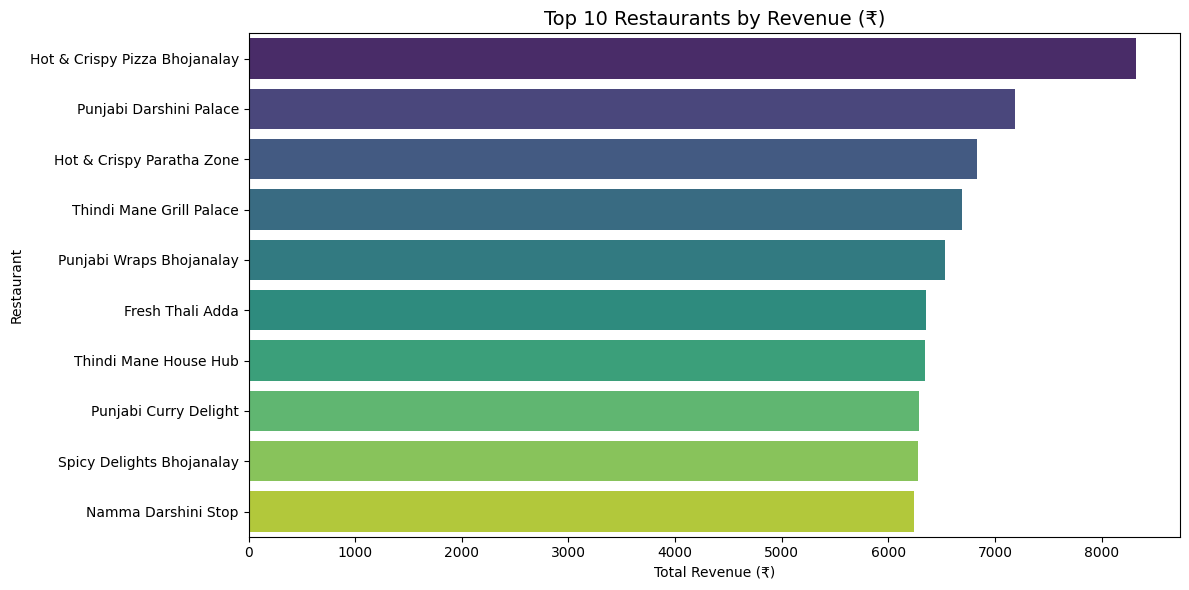


Insight: These are your star restaurant partners — invest in retaining them.


In [42]:
rest_rev = active.groupby('restaurant_id').agg(
    revenue = ('total_amount', 'sum'),
    orders  = ('order_id', 'count')
).reset_index()
rest_rev = rest_rev.merge(
    restaurant[['restaurant_id','restaurant_name','cuisine_type']],
    on='restaurant_id'
)
top10 = rest_rev.sort_values('revenue', ascending=False).head(10)
print(top10[['restaurant_name','cuisine_type','revenue','orders']].to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=top10, x='revenue', y='restaurant_name', palette='viridis', ax=ax)
ax.set_title('Top 10 Restaurants by Revenue (₹)', fontsize=14)
ax.set_xlabel('Total Revenue (₹)'); ax.set_ylabel('Restaurant')
plt.tight_layout()
plt.savefig('q12_top_restaurants.png', dpi=120, bbox_inches='tight')
plt.show()
print('\nInsight: These are your star restaurant partners — invest in retaining them.')

---
##  Final Summary — Key Business Metrics


In [32]:
total_revenue  = active['total_amount'].sum()
total_orders   = len(orders)
cancel_pct     = orders['is_cancelled_flag'].mean() * 100
avg_order_val  = active['total_amount'].mean()
avg_rating     = ratings['rating'].mean()
late_pct       = delivery['is_late'].mean() * 100
avg_discount   = orders['discount_amount'].mean()
top_city       = city_stats.iloc[0]['customer_city']

summary = {
    'Total Orders Placed'   : f'{total_orders:,}',
    'Completed Orders'      : f'{len(active):,}',
    'Cancellation Rate'     : f'{cancel_pct:.2f}%',
    'Total Revenue'         : f'₹{total_revenue:,.0f}',
    'Avg Order Value'       : f'₹{avg_order_val:.2f}',
    'Avg Discount Given'    : f'₹{avg_discount:.2f}',
    'Avg Customer Rating'   : f'{avg_rating:.2f} / 5',
    'Late Delivery Rate'    : f'{late_pct:.2f}%',
    'Top Revenue City'      : top_city
}

print('=' * 50)
print('  FOOD DELIVERY STARTUP — FINAL KPI REPORT')
print('=' * 50)
for k, v in summary.items():
    print(f'  {k:<30} {v}')
print('=' * 50)
print('\nAnalysis Complete! All charts saved as PNG files.')

  FOOD DELIVERY STARTUP — FINAL KPI REPORT
  Total Orders Placed            149,166
  Completed Orders               138,054
  Cancellation Rate              7.45%
  Total Revenue                  ₹48,561,116
  Avg Order Value                ₹351.75
  Avg Discount Given             ₹18.89
  Avg Customer Rating            4.05 / 5
  Late Delivery Rate             63.84%
  Top Revenue City               Bengaluru

✅ Analysis Complete! All charts saved as PNG files.
